In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 43.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit.DataStructs.cDataStructs import ConvertToNumpyArray
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/final_gene_drug_links_with_uniprot.csv")
df = df.dropna(subset=[
    "Canonical SMILES", "UniProt", "CombinedScore"
    ]).reset_index(drop=True)

# Create binary activity label
df["Label"] = (df["CombinedScore"] >= 5.59).astype(int)

# Molecule featurisation
def featurise_molecule(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((1,), dtype=int)
    ConvertToNumpyArray(fp, arr)
    descriptors = [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
    ]
    return arr, descriptors

fp_list, desc_list, valid_indices = [], [], []
for idx, smi in enumerate(df["Canonical SMILES"]):
    fp, desc = featurise_molecule(smi)
    if fp is not None:
        fp_list.append(fp)
        desc_list.append(desc)
        valid_indices.append(idx)

df = df.iloc[valid_indices].reset_index(drop=True)
X_mol = np.array(fp_list)
X_desc = np.array(desc_list)

# Protein featurisation
df["UniProt"] = df["UniProt"].str.split(",").apply(lambda x: [i.strip() for i in x])
mlb = MultiLabelBinarizer()
X_protein = mlb.fit_transform(df["UniProt"])

# Tabular features (TS + others soon)
X_tab = df[["TargetabilityScore_y"]].fillna(0).values
X_tab = StandardScaler().fit_transform(X_tab)

# Combine all features
X = np.hstack([X_mol, X_desc, X_protein, X_tab])
y = df["Label"].values

print(f"Feature matrix shape: {X.shape}, Label vector shape: {y.shape}")

Streaming output truncated to the last 5000 lines.
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:56:07] DEPRECATION WARNING: please use MorganGenerator
[09:5

Feature matrix shape: (91151, 2108), Label vector shape: (91151,)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                Model  Accuracy  F1 Score   ROC AUC
0        RandomForest  0.973891  0.588946  0.973060
1    GradientBoosting  0.969393  0.398707  0.960452
2  LogisticRegression  0.970380  0.532062  0.968241
3                 SVM  0.962756  0.000000  0.951079
4                 KNN  0.965224  0.360887  0.826526
5          NaiveBayes  0.876090  0.340438  0.946223


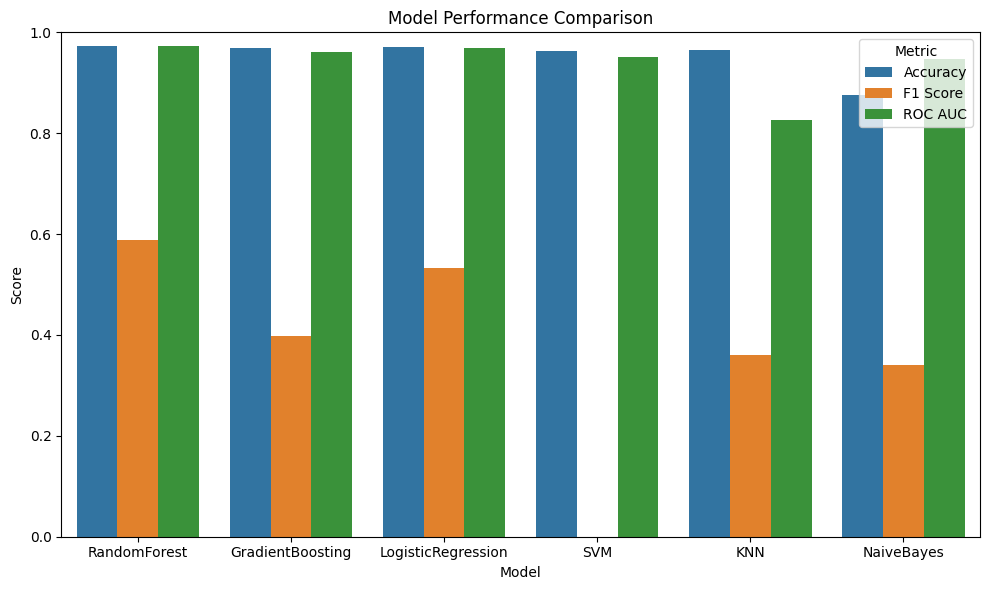

In [ ]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Define models
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NaiveBayes": BernoulliNB()
}

# Train and evaluate
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1,
        "ROC AUC": roc
    })

results_df = pd.DataFrame(results)
print(results_df)

# Plot results
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df.melt(id_vars="Model"), x="Model", y="value", hue="variable")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()